## Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Task 1: Read the Pantheon+SH0ES data table

In [2]:
# .dat files in astronomy are typically space-separated or tab-separated.
# We use '\s+' to handle any amount of whitespace between columns.
file_path = 'data/Pantheon+SH0ES.dat'

try:
    df = pd.read_csv(file_path, sep=r'\s+')
    print("Dataset loaded successfully.")
    #print the head and tail of the data file
    display(df.head())
    display(df.tail())
except FileNotFoundError:
    print(f"Error: The file {file_path} was not found. Please ensure it is in the same directory.")

Dataset loaded successfully.


,CID,IDSURVEY,zHD,zHDERR,zCMB,zCMBERR,zHEL,zHELERR,m_b_corr,m_b_corr_err_DIAG,...,PKMJDERR,NDOF,FITCHI2,FITPROB,m_b_corr_err_RAW,m_b_corr_err_VPEC,biasCor_m_b,biasCorErr_m_b,biasCor_m_b_COVSCALE,biasCor_m_b_COVADD
0,2011fe,51,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.74571,1.516210,...,0.1071,36,26.8859,0.864470,0.0991,1.4960,0.0381,0.005,1.0,0.003
1,2011fe,56,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.80286,1.517230,...,0.0579,101,88.3064,0.812220,0.0971,1.4960,-0.0252,0.003,1.0,0.004
2,2012cg,51,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.47030,0.781906,...,0.0278,165,233.5000,0.000358,0.0399,0.7134,0.0545,0.019,1.0,0.036
3,2012cg,56,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.49190,0.798612,...,0.0667,55,100.1220,0.000193,0.0931,0.7134,0.0622,0.028,1.0,0.040
4,1994DRichmond,50,0.00299,0.00084,0.00299,0.00004,0.00187,0.00004,11.52270,0.880798,...,0.0522,146,109.8390,0.988740,0.0567,0.6110,0.0650,0.009,1.0,0.006


,CID,IDSURVEY,zHD,zHDERR,zCMB,zCMBERR,zHEL,zHELERR,m_b_corr,m_b_corr_err_DIAG,...,PKMJDERR,NDOF,FITCHI2,FITPROB,m_b_corr_err_RAW,m_b_corr_err_VPEC,biasCor_m_b,biasCorErr_m_b,biasCor_m_b_COVSCALE,biasCor_m_b_COVADD
1696,rutledge,106,1.61505,0.00545,1.61499,0.005,1.61399,0.005,25.9065,0.331927,...,1.7256,8,2.92493,0.93898,0.2230,0.0106,-0.0203,0.005,1.000,0.002
1697,geta,106,1.69706,0.04006,1.69702,0.040,1.70000,0.040,26.0333,0.379521,...,1.8973,12,9.15387,0.68973,0.3209,0.0748,0.2680,0.005,0.633,0.000
1698,stone,106,1.80119,0.02014,1.80111,0.020,1.80000,0.020,26.2335,0.280685,...,1.1631,11,11.69320,0.38714,0.2370,0.0358,-0.0968,0.004,0.641,0.000
1699,wilson,106,1.91165,0.00263,1.91160,0.001,1.91401,0.001,26.1703,0.357624,...,1.4902,9,5.54378,0.78457,0.3168,0.0044,-0.3835,0.013,0.604,0.000
1700,colfax,106,2.26137,0.02018,2.26130,0.020,2.26000,0.020,26.9298,0.280011,...,5.6828,13,10.19320,0.67807,0.4455,0.0297,-0.5356,0.009,0.164,0.000


## Task 2 - Confirm required columns exist

In [3]:
required_columns = ['zCMB', 'zHEL', 'm_b_corr', 'CEPH_DIST', 'IS_CALIBRATOR']
missing_cols = [col for col in required_columns if col not in df.columns]

if not missing_cols:
    print("Verification: All required columns exist in the dataset.")
else:
    print(f"Error: Missing columns: {missing_cols}")

Verification: All required columns exist in the dataset.


## Task 3 - Count the total number of supernovae

In [4]:
total_observations = len(df)
print(f"Total number of supernova observations (rows): {total_observations}")

Total number of supernova observations (rows): 1701


## Task 4 - Identify the subset of Cepheid calibrators

In [5]:
# The IS_CALIBRATOR column is a flag where 1 typically means Cepheid calibrators
calibrators = df[df['IS_CALIBRATOR'] == 1]
print(f"Number of Cepheid calibrator objects: {len(calibrators)}")

Number of Cepheid calibrator objects: 77


## Task 5 - Inspect whether relevant columns contain finite values

In [6]:
print("Data Validation (Checking for NaNs or Infinite values):")
for col in required_columns:
    nan_count = df[col].isna().sum()
    inf_count = np.isinf(df[col]).sum()
    
    print(f" - Column '{col}': {nan_count} NaNs, {inf_count} Infs")

Data Validation (Checking for NaNs or Infinite values):
 - Column 'zCMB': 0 NaNs, 0 Infs
 - Column 'zHEL': 0 NaNs, 0 Infs
 - Column 'm_b_corr': 0 NaNs, 0 Infs
 - Column 'CEPH_DIST': 0 NaNs, 0 Infs
 - Column 'IS_CALIBRATOR': 0 NaNs, 0 Infs


## Task 6

### Part 1 - Produce a Histogram of zCMB

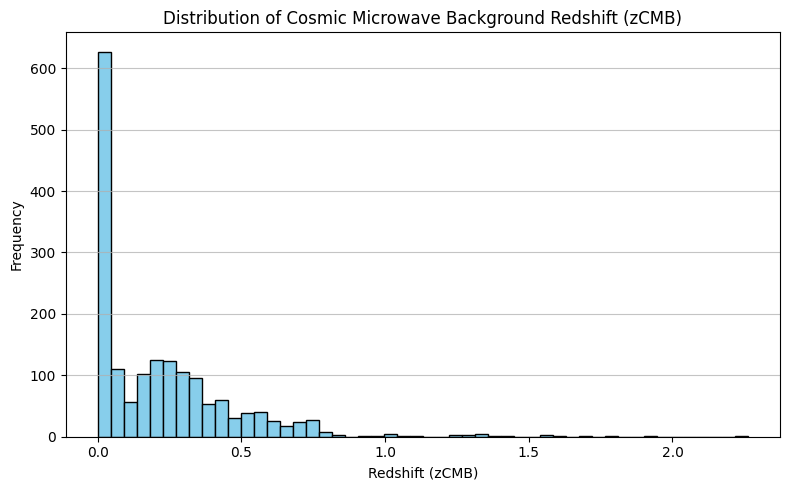

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df['zCMB'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Cosmic Microwave Background Redshift (zCMB)')
plt.xlabel('Redshift (zCMB)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### Part 2 - Produce a Scatter plot (Hubble Diagram)

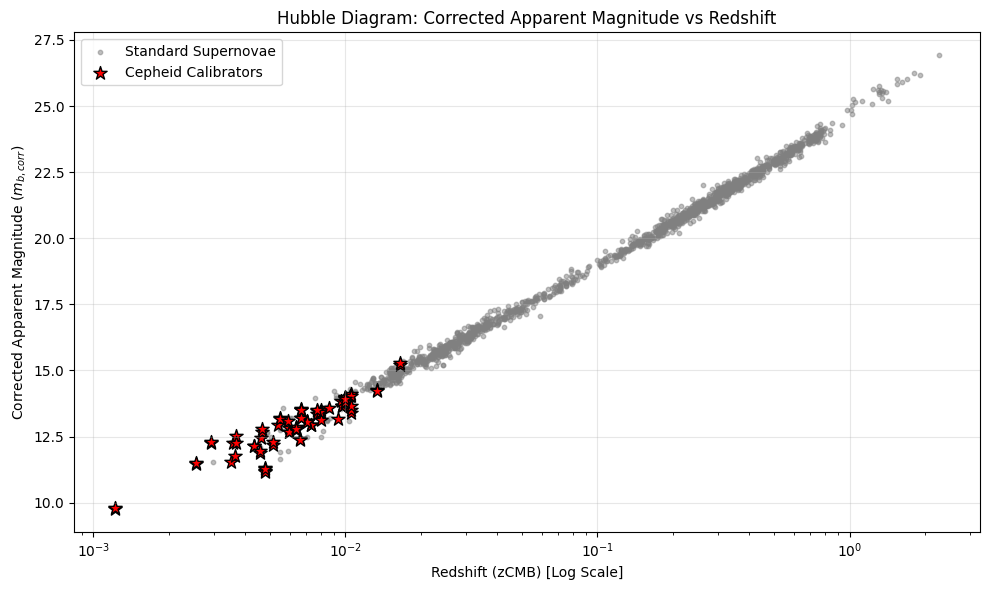

In [8]:
plt.figure(figsize=(10, 6))

# Plot the standard sample (IS_CALIBRATOR == 0)
standard_sn = df[df['IS_CALIBRATOR'] == 0]
plt.scatter(standard_sn['zCMB'], standard_sn['m_b_corr'], 
            color='gray', alpha=0.5, s=10, label='Standard Supernovae')

# Plot the calibrators on top (IS_CALIBRATOR == 1)
plt.scatter(calibrators['zCMB'], calibrators['m_b_corr'], 
            color='red', marker='*', s=100, edgecolor='black', label='Cepheid Calibrators')

plt.title('Hubble Diagram: Corrected Apparent Magnitude vs Redshift')
plt.xlabel('Redshift (zCMB) [Log Scale]')
plt.ylabel('Corrected Apparent Magnitude ($m_{b,corr}$)')

# It is standard practice to plot redshift on a logarithmic scale in Hubble Diagrams
plt.xscale('log') 
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

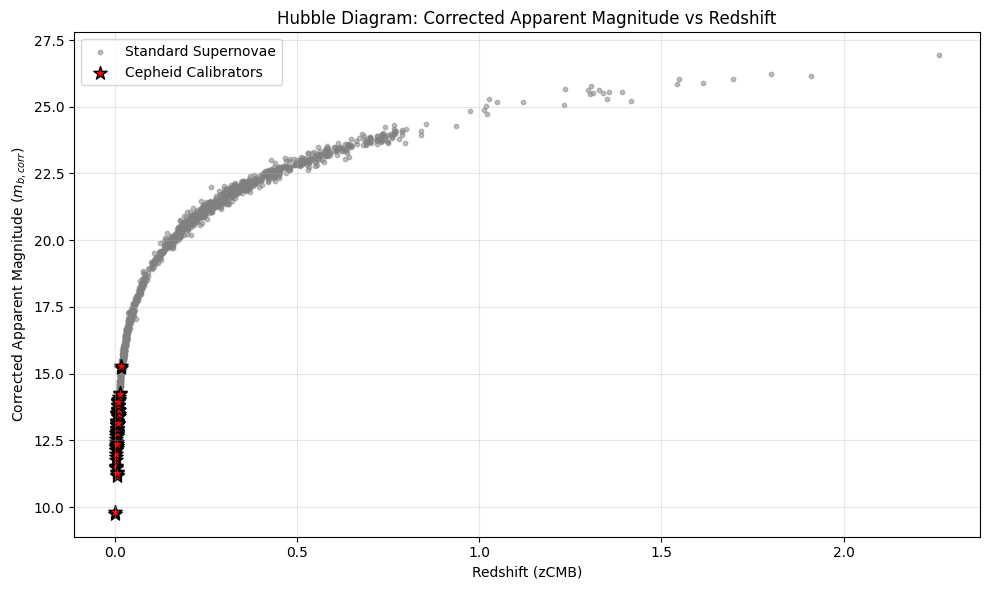

In [9]:
plt.figure(figsize=(10, 6))

# Plot the standard sample (IS_CALIBRATOR == 0)
standard_sn = df[df['IS_CALIBRATOR'] == 0]
plt.scatter(standard_sn['zCMB'], standard_sn['m_b_corr'], 
            color='gray', alpha=0.5, s=10, label='Standard Supernovae')

# Plot the calibrators on top (IS_CALIBRATOR == 1)
plt.scatter(calibrators['zCMB'], calibrators['m_b_corr'], 
            color='red', marker='*', s=100, edgecolor='black', label='Cepheid Calibrators')

plt.title('Hubble Diagram: Corrected Apparent Magnitude vs Redshift')
plt.xlabel('Redshift (zCMB)')
plt.ylabel('Corrected Apparent Magnitude ($m_{b,corr}$)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()